In [1]:
import numpy as np
from jetgp.wdegp.wdegp import wdegp
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 12})

# Define test function: f(x) = sin(10*pi*x)/(2*x) + (x-1)^4
def f_fun(x):
    return np.sin(10*np.pi*x)/(2*x) + (x-1)**4

def f1_fun(x):  # First derivative
    return (10*np.pi*np.cos(10*np.pi*x))/(2*x) - \
           np.sin(10*np.pi*x)/(2*x**2) + 4*(x-1)**3

def f2_fun(x):  # Second derivative
    return -(100*np.pi**2*np.sin(10*np.pi*x))/(2*x) - \
           (20*np.pi*np.cos(10*np.pi*x))/(2*x**2) + \
           np.sin(10*np.pi*x)/(x**3) + 12*(x-1)**2

# Generate training points
X_all = np.linspace(0.5, 2.5, 10).reshape(-1, 1)

# Partition into two submodels (alternating points)
submodel1_indices = [0, 2, 4, 6, 8]
submodel2_indices = [1, 3, 5, 7, 9]

# Reorder for contiguous indexing
X_train = np.vstack([X_all[submodel1_indices],
                     X_all[submodel2_indices]])
y_vals = f_fun(X_train.flatten()).reshape(-1, 1)

print("Training data prepared with 2 submodels (5 points each)")

/home/sam/anaconda3/envs/pyoti_2/lib/python3.9/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)


Training data prepared with 2 submodels (5 points each)


In [2]:
# Compute derivatives for each submodel
d1_sm1 = np.array([[f1_fun(X_train[i,0])] for i in range(5)])
d2_sm1 = np.array([[f2_fun(X_train[i,0])] for i in range(5)])
d1_sm2 = np.array([[f1_fun(X_train[i,0])] for i in range(5,10)])
d2_sm2 = np.array([[f2_fun(X_train[i,0])] for i in range(5,10)])

# Package submodel data
submodel_data = [
    [y_vals, d1_sm1, d2_sm1],  # Submodel 1
    [y_vals, d1_sm2, d2_sm2]   # Submodel 2
]

submodel_indices = [[0,1,2,3,4], [5,6,7,8,9]]
derivative_specs = [[[[[1,1]]], [[[1,2]]]], [[[[1,1]]], [[[1,2]]]]]

print("Initializing WDEGP model...")

Initializing WDEGP model...


In [3]:
# Initialize and optimize
model = wdegp(X_train, submodel_data, n_order=2, n_bases=1,
              index=submodel_indices,
              der_indices=derivative_specs,
              normalize=True, kernel="SE",
              kernel_type="anisotropic")

print("Optimizing hyperparameters...")
params = model.optimize_hyperparameters(optimizer='jade',
                                         pop_size=100,
                                         n_generations=15)

print("Optimization complete!")

Optimizing hyperparameters...


Optimization complete!


In [4]:
# Predict
X_test = np.linspace(0.5, 2.5, 250).reshape(-1, 1)
y_pred, y_cov, submodel_preds, submodel_covs = model.predict(X_test, params, calc_cov=True, return_submodels = True)

# Predict individual submodels
y_pred_sm1 = submodel_preds[0].flatten()
y_cov_sm1  = submodel_covs[0].flatten()

y_pred_sm2 = submodel_preds[1].flatten()
y_cov_sm2  = submodel_covs[1].flatten()

# Compute true function
y_true = f_fun(X_test.flatten())

# Compute confidence intervals (95%)
std_global = np.sqrt(y_cov)
std_sm1 = np.sqrt(y_cov_sm1)
std_sm2 = np.sqrt(y_cov_sm2)

print(f"Predictions complete for {len(X_test)} test points")

Predictions complete for 250 test points


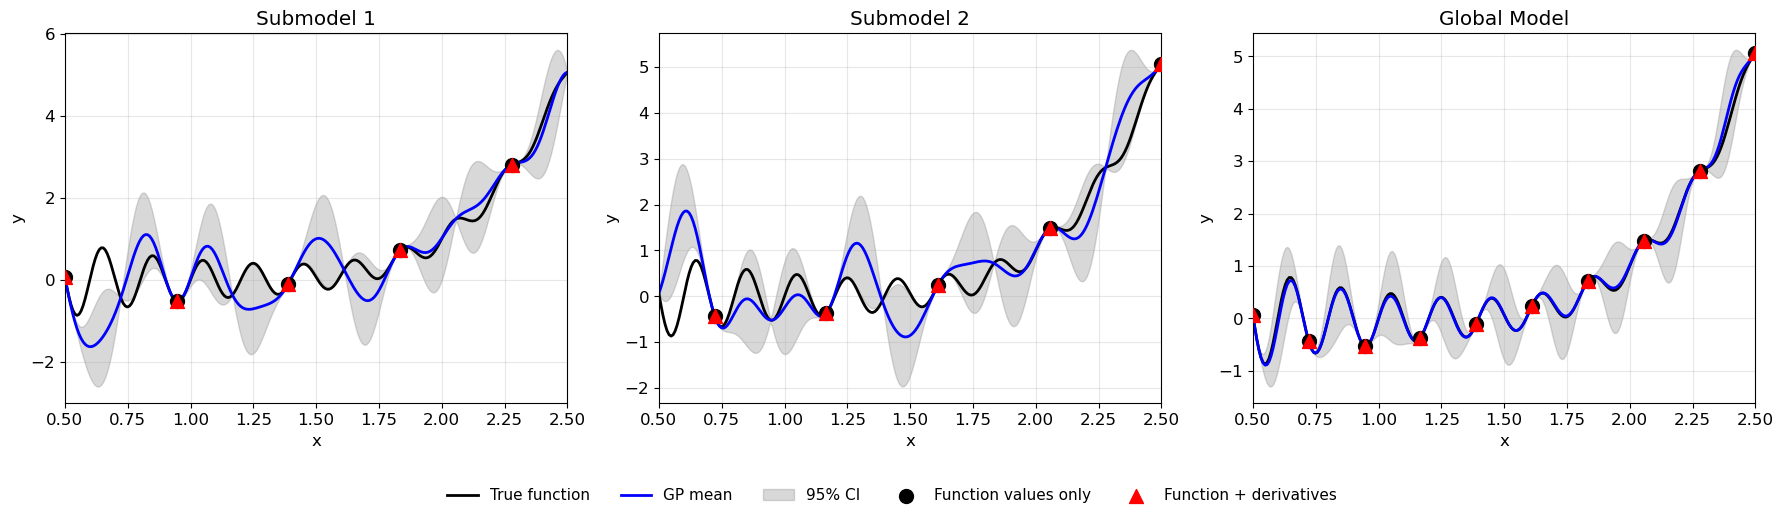

In [5]:
# Create visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Submodel 1
axes[0].plot(X_test, y_true, 'k-', linewidth=2, label='True function')
axes[0].plot(X_test, y_pred_sm1, 'b-', linewidth=2, label='GP mean')
axes[0].fill_between(X_test.flatten(),
                     y_pred_sm1.flatten() - 1.96*std_sm1,
                     y_pred_sm1.flatten() + 1.96*std_sm1,
                     color='gray', alpha=0.3, label='95% CI')
axes[0].scatter(X_train[:5], y_vals[:5], c='black', s=100,
                zorder=5, marker='o', label='Function values only')
axes[0].scatter(X_train[:5], y_vals[:5], c='red', s=100,
                zorder=6, marker='^', label='Function + derivatives')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('Submodel 1')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0.5, 2.5])

# Submodel 2
axes[1].plot(X_test, y_true, 'k-', linewidth=2, label='True function')
axes[1].plot(X_test, y_pred_sm2, 'b-', linewidth=2, label='GP mean')
axes[1].fill_between(X_test.flatten(),
                     y_pred_sm2.flatten() - 1.96*std_sm2,
                     y_pred_sm2.flatten() + 1.96*std_sm2,
                     color='gray', alpha=0.3, label='95% CI')
axes[1].scatter(X_train[5:], y_vals[5:], c='black', s=100,
                zorder=5, marker='o')
axes[1].scatter(X_train[5:], y_vals[5:], c='red', s=100,
                zorder=6, marker='^')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_title('Submodel 2')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0.5, 2.5])

# Global Model
axes[2].plot(X_test, y_true, 'k-', linewidth=2, label='True function')
axes[2].plot(X_test, y_pred.flatten(), 'b-', linewidth=2, label='GP mean')
axes[2].fill_between(X_test.flatten(),
                     y_pred.flatten() - 1.96*std_global,
                     y_pred.flatten() + 1.96*std_global,
                     color='gray', alpha=0.3, label='95% CI')
axes[2].scatter(X_train[:5], y_vals[:5], c='black', s=100,
                zorder=5, marker='o')
axes[2].scatter(X_train[:5], y_vals[:5], c='red', s=100,
                zorder=6, marker='^')
axes[2].scatter(X_train[5:], y_vals[5:], c='black', s=100,
                zorder=5, marker='o')
axes[2].scatter(X_train[5:], y_vals[5:], c='red', s=100,
                zorder=6, marker='^')
axes[2].set_xlabel('x')
axes[2].set_ylabel('y')
axes[2].set_title('Global Model')
axes[2].grid(True, alpha=0.3)
axes[2].set_xlim([0.5, 2.5])

# Create legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5,
           frameon=False, fontsize=11, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()